# Detekcija anomalija u financijskim transakcijama: algoritam izolacijskih stabala

Ova bilježnica implementira i evaluira algoritam izolacijskih stabala (engl. *Isolation Forest*) za detekciju prijevarnih transakcija, korištenjem skupa podataka Credit Card Fraud Detection (ULB, Kaggle).

Struktura prati poglavlje 4.4. završnog rada *Izrada prototipa sustava za detekciju anomalija u financijskim sustavima u stvarnom vremenu primjenom metoda strojnog učenja*. Metrike evaluacije definirane su u skladu s
poglavljem 3.4.

In [19]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
#!pip install - q joblib

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score , precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
import joblib

RANDOM_STATE = 42

## 1. Učitavanje podataka

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

df = pd.read_csv(f"{path}/creditcard.csv")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Eksplorativna analiza podataka (EDA)

In [3]:
print(df['Class'].value_counts())
print(f"Fraud rate: {df['Class'].mean() * 100:.4f} %")

df['Amount'].describe()

Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727 %


,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


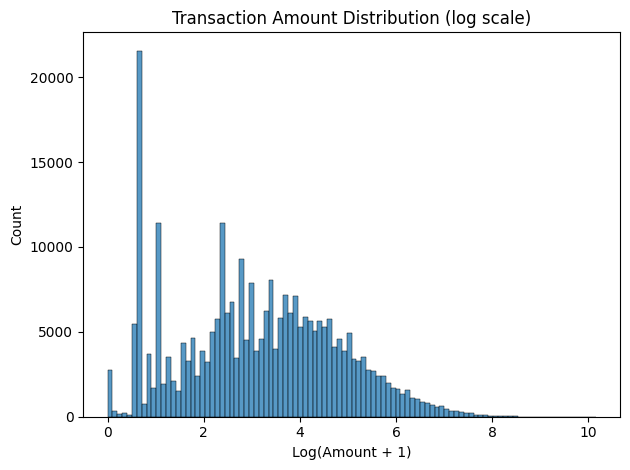

In [4]:
sns.histplot(np.log1p(df['Amount']), bins=100)
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('Log(Amount + 1)')
plt.tight_layout()
plt.show()

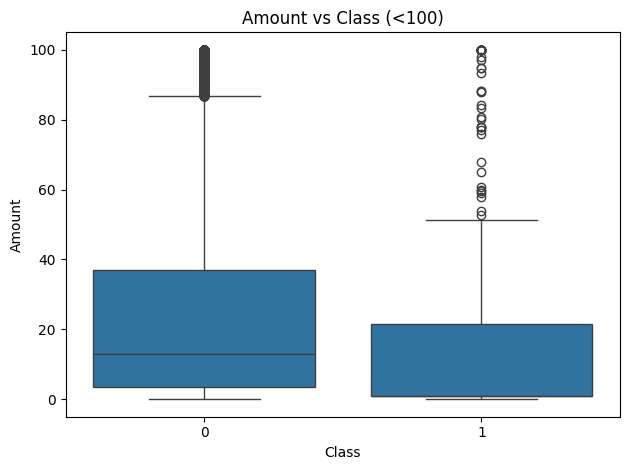

In [5]:
sns.boxplot(data=df[df['Amount']<100], x='Class', y='Amount')
plt.title('Amount vs Class (<100)')
plt.tight_layout()
plt.show()

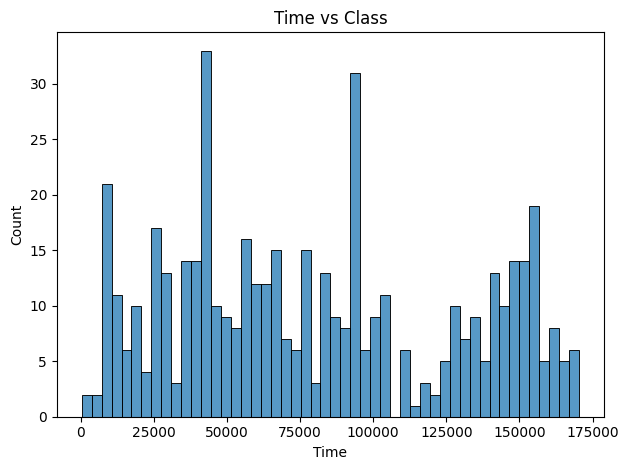

In [6]:
sns.histplot(data=df[df['Class'] == 1], x='Time', bins=50)
plt.title('Time vs Class')
plt.tight_layout()
plt.show()

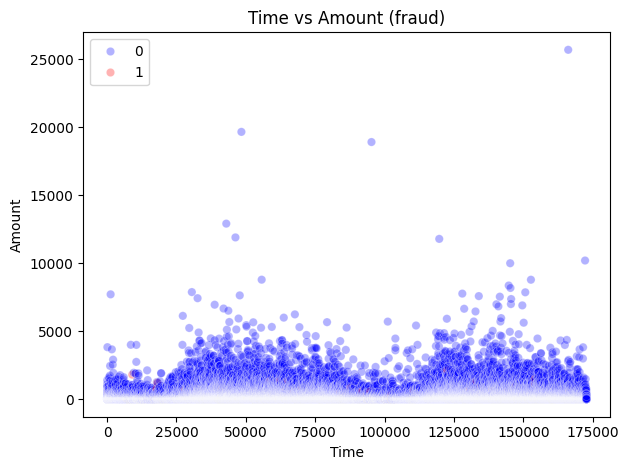

In [7]:
sns.scatterplot(data=df, x='Time', y='Amount', hue='Class', palette={0: 'blue', 1: 'red'}, alpha=0.3)
plt.title('Time vs Amount (fraud)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Predobrada podataka

Značajke V1-V28 već su rezultat PCA transformacije originalnog skupa pa ih nije potrebno dodatno skalirati. Time i Amount skaliramo zasebno.

Podjela na trening i test skup provodi se prema stupcu Time (kronološki), a ne nasumično. Time se simulira način rada sustava u stvarnom vremenu, gdje se model trenira na starijim transakcijama, a testira na novijima koje tijekom treniranja nije vidio.

In [8]:
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

In [9]:
amount_scaler = RobustScaler()
train_df['Amount_scaled'] = amount_scaler.fit_transform(train_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
train_df['Time_scaled'] = time_scaler.fit_transform(train_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

In [10]:
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_test = test_df['Class']

print(f"Train: {X_train.shape}, Fraud rate: {train_df['Class'].mean() * 100:.4f} %")
print(f"Test: {X_test.shape}, Fraud rate: {y_test.mean() * 100:.4f} %")

Train: (199364, 30), Fraud rate: 0.1926 %
Test: (85443, 30), Fraud rate: 0.1264 %


## 4. Treniranje modela

In [11]:
# Parametar contamination procjenjujemo iz stvarnog udjela anomalija u trening skupu
contamination_rate = train_df['Class'].mean()

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_forest.fit(X_train)

IsolationForest(contamination=np.float64(0.0019261250777472363),
                n_estimators=200, n_jobs=-1, random_state=42)

## 5. Anomalijski rezultat i evaluacija

Accuracy: 0.9972
Precision: 0.00000000
Recall: 0.00000000
F1-score: 0.00000000
ROC-AUC: 0.9399
PR-AUC: 0.0351


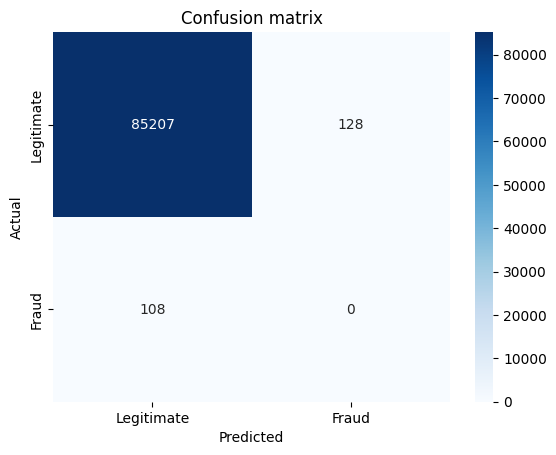

In [12]:
# score_samples: veće vrijednosti = normalnije ponašanje, stoga okrećemo predznak
# kako bi veći rezultat označavao veću anomalnost (u skladu s poglavljem 3.1.)
anomaly_scores = -iso_forest.score_samples(X_test)
y_pred = (iso_forest.predict(X_test) == -1).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, anomaly_scores)
pr_auc = average_precision_score(y_test, anomaly_scores)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.8f}")
print(f"Recall: {recall:.8f}")
print(f"F1-score: {f1:.8f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

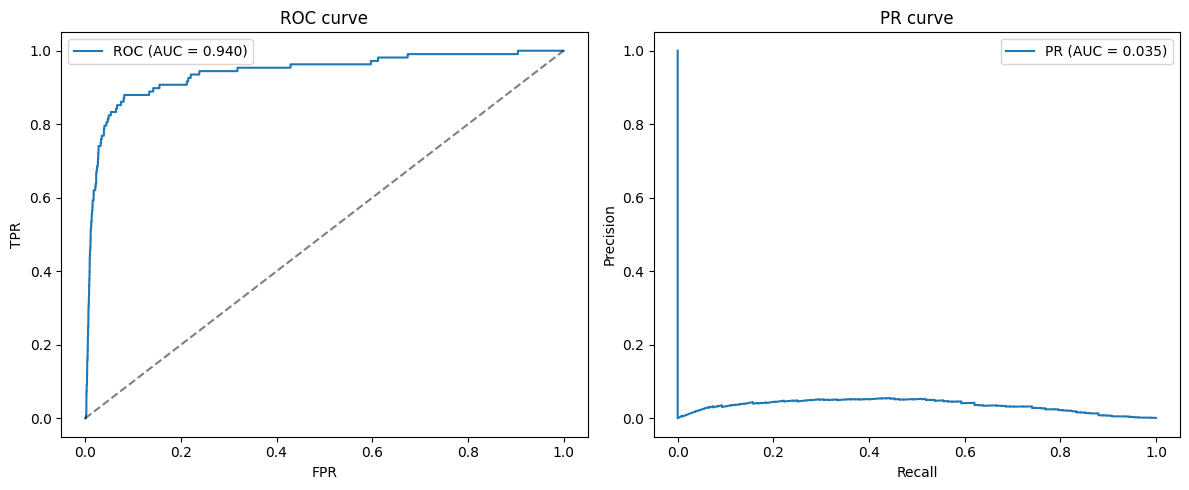

In [13]:
fpr, tpr, _ = roc_curve(y_test, anomaly_scores)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, anomaly_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()
plt.tight_layout()
plt.show()

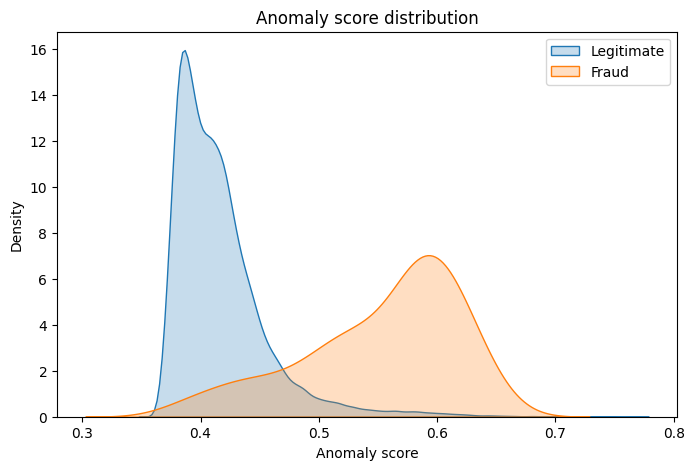

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(anomaly_scores[y_test == 0], label='Legitimate', fill=True)
sns.kdeplot(anomaly_scores[y_test == 1], label='Fraud', fill=True)
plt.xlabel('Anomaly score')
plt.title('Anomaly score distribution')
plt.legend()
plt.show()

## 5.1. Optimizacija praga odlučivanja
Prag koji IsolationForest.predict() koristi interno (izveden iz parametra contamination) doveo je do 0 % odziva unatoč solidnom ROC-AUC-u, što pokazuje da fiksni prag temeljen na pretpostavljenom udjelu anomalija nije nužno optimalan izbor. U nastavku se prag bira izravno na temelju već izračunatih anomalijskih rezultata (anomaly_scores), kao onaj koji maksimizira F1-mjeru na PR krivulji, umjesto da se oslanja na ugrađenu odluku modela.

Optimal threshold (max F1-score): 0.5835
Precision: 0.0552
Recall: 0.4444
F1-score: 0.0982


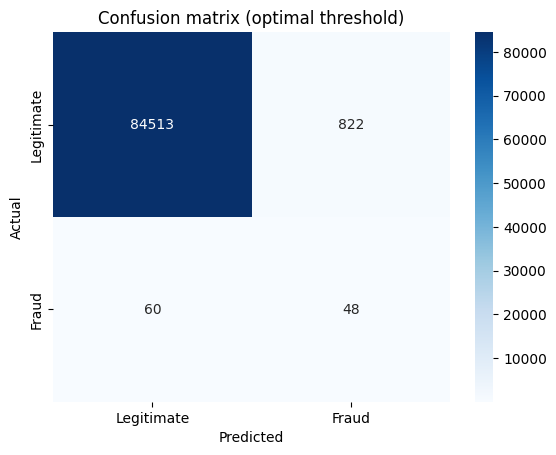

In [14]:
prec_vals, rec_vals, thresholds_pr = precision_recall_curve(y_test, anomaly_scores)

f1_vals = 2 * prec_vals * rec_vals / (prec_vals + rec_vals + 1e-12)
best_idx = np.argmax(f1_vals[:-1])
best_threshold = thresholds_pr[best_idx]

print(f"Optimal threshold (max F1-score): {best_threshold:.4f}")
print(f"Precision: {prec_vals[best_idx]:.4f}")
print(f"Recall: {rec_vals[best_idx]:.4f}")
print(f"F1-score: {f1_vals[best_idx]:.4f}")

y_pred_optimal = (anomaly_scores >= best_threshold).astype(int)

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion matrix (optimal threshold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5.2. Kompromis preciznosti i odziva pri različitim pragovima

F1-optimalni prag predstavlja samo jednu točku na PR krivulji, onu u kojoj su preciznost i odziv jednako vrednovani. U nastavku se prikazuje nekoliko dodatnih točaka duž iste krivulje, za nekoliko ciljanih razina odziva, kako bi se dobio potpuniji uvid u to koliko preciznosti je potrebno "žrtvovati" za svaku dodatnu razinu uhvaćenih prijevara.

In [15]:
target_recalls = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

rows = []
for target in target_recalls:
    valid_idx = np.where(rec_vals[:-1] >= target)[0]
    if len(valid_idx) == 0:
        continue
    idx = valid_idx[-1]
    rows.append({
        'Target recall': target,
        'Threshold': round(thresholds_pr[idx], 4),
        'Precision': round(prec_vals[idx], 4),
        'Recall': round(rec_vals[idx], 4),
        'F1-score': round(f1_vals[idx], 4)
    })

trade_off_df = pd.DataFrame(rows)
trade_off_df

,Target recall,Threshold,Precision,Recall,F1-score
0,0.2,0.6071,0.0455,0.2037,0.0743
1,0.3,0.5959,0.0518,0.3056,0.0886
2,0.4,0.5848,0.0526,0.4074,0.0932
3,0.5,0.5758,0.0523,0.5000,0.0947
4,0.6,0.5509,0.0416,0.6019,0.0778
5,0.7,0.5252,0.0323,0.7037,0.0618


## 5.3. Eksperiment: utjecaj parametra max_samples

Defaultna vrijednost (max_samples='auto') ograničava svako stablo na tek 256 uzoraka po podstablu, neovisno o veličini trening skupa (~199 000 redaka). Kako bismo provjerili utječe li to na kvalitetu detekcije, treniramo dodatni model s većim max_samples i uspoređujemo PR-AUC i ROC-AUC oba modela na istom testnom skupu.

In [17]:
iso_forest_v2 = IsolationForest(
    n_estimators=200,
    max_samples=2048,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest_v2.fit(X_train)

anomaly_scores_v2 = -iso_forest_v2.score_samples(X_test)
pr_auc_v2 = average_precision_score(y_test, anomaly_scores_v2)
roc_auc_v2 = roc_auc_score(y_test, anomaly_scores_v2)

print(f"max_samples='auto' (base model): PR-AUC = {pr_auc:.4f}, ROC-AUC = {roc_auc:.4f}")
print(f"max_samples=2048 (new model):    PR-AUC = {pr_auc_v2:.4f}, ROC-AUC = {roc_auc_v2:.4f}")

max_samples='auto' (base model): PR-AUC = 0.0351, ROC-AUC = 0.9399
max_samples=2048 (new model):    PR-AUC = 0.0531, ROC-AUC = 0.9448


### 5.3.1. Optimizacija praga za poboljšani model

Budući da model s max_samples=2048 pokazuje bolji PR-AUC i ROC-AUC od baznog modela, usvajamo ga kao finalnu konfiguraciju za ostatak evaluacije. Ponavljamo postupak optimizacije praga (kao u 5.1.), ovaj put na anomaly_scores_v2.

Optimal threshold (max_samples=2048): 0.5558
Precision: 0.0900
Recall: 0.4815
F1-score: 0.1516


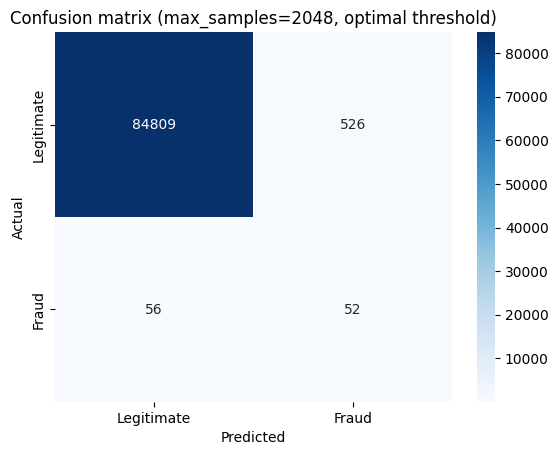

In [22]:
prec_vals_v2, rec_vals_v2, thresholds_pr_v2 = precision_recall_curve(y_test, anomaly_scores_v2)

f1_vals_v2 = 2 * prec_vals_v2 * rec_vals_v2 / (prec_vals_v2 + rec_vals_v2 + 1e-12)
best_idx_v2 = np.argmax(f1_vals_v2[:-1])
best_threshold_v2 = thresholds_pr_v2[best_idx_v2]

print(f"Optimal threshold (max_samples=2048): {best_threshold_v2:.4f}")
print(f"Precision: {prec_vals_v2[best_idx_v2]:.4f}")
print(f"Recall: {rec_vals_v2[best_idx_v2]:.4f}")
print(f"F1-score: {f1_vals_v2[best_idx_v2]:.4f}")

y_pred_v2_optimal = (anomaly_scores_v2 >= best_threshold_v2).astype(int)

cm_v2_optimal = confusion_matrix(y_test, y_pred_v2_optimal)
sns.heatmap(cm_v2_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion matrix (max_samples=2048, optimal threshold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 5.3.2. Kompromis preciznosti i odziva za poboljšani model

Isti prikaz kao u 5.2., ali za poboljšani model (max_samples=2048), radi izravne usporedbe s baznim modelom.

In [23]:
rows_v2 = []
for target in target_recalls:
    valid_idx = np.where(rec_vals_v2[:-1] >= target)[0]
    if len(valid_idx) == 0:
        continue
    idx = valid_idx[-1]
    rows_v2.append({
        'Target recall': target,
        'Threshold': round(thresholds_pr_v2[idx], 4),
        'Precision': round(prec_vals_v2[idx], 4),
        'Recall': round(rec_vals_v2[idx], 4),
        'F1-score': round(f1_vals_v2[idx], 4)
    })

trade_off_df_v2 = pd.DataFrame(rows_v2)
trade_off_df_v2

,Target recall,Threshold,Precision,Recall,F1-score
0,0.2,0.5892,0.0731,0.2037,0.1076
1,0.3,0.5742,0.0801,0.3056,0.1269
2,0.4,0.5630,0.0854,0.4074,0.1413
3,0.5,0.5507,0.0857,0.5000,0.1463
4,0.6,0.5241,0.0667,0.6019,0.1200
5,0.7,0.4837,0.0454,0.7037,0.0853


## 5.4. Vizualizacija distribucije klasa i granice odlučivanja (2D projekcija)

Stvarni model radi u 30-dimenzijskom prostoru značajki, koji se ne može izravno prikazati na grafu. Kako bismo ipak vizualizirali kako model razdvaja klase, podatci se projiciraju u dvodimenzijski prostor pomoću PCA-e (isključivo za potrebe vizualizacije, odvojeno od stvarnog 30D modela). Na toj se projekciji trenira zaseban, ilustrativni Isolation Forest (isti pristup koji koriste i drugi izvori pri vizualizaciji granica odlučivanja modela treniranih na višedimenzijskim podatcima [19]).

Rezultat je pozadinski prikaz anomalijskog rezultata s
označenom granicom odlučivanja, preko kojeg su prikazane stvarne test transakcije obojene prema
stvarnoj klasi.

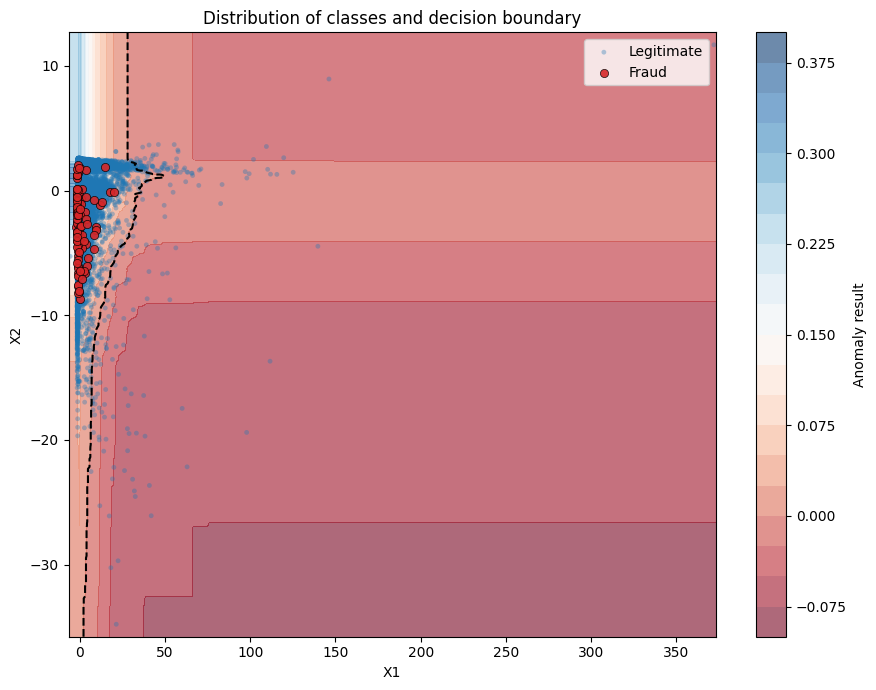

In [20]:
visual_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = visual_pca.fit_transform(X_train)
X_test_2d = visual_pca.transform(X_test)

iso_forest_2d = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest_2d.fit(X_train_2d)

x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = iso_forest_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=1.5, linestyles='--')
plt.colorbar(contour, ax=ax, label='Anomaly result')

for cls, color, label, size, alpha in [
    (0, 'tab:blue', 'Legitimate', 12, 0.35),
    (1, 'tab:red', 'Fraud', 35, 0.9),
]:
    mask = (y_test == cls).values
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=color, s=size, alpha=alpha,
               edgecolors='k' if cls == 1 else 'none', linewidths=0.5,
               label=label)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Distribution of classes and decision boundary')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Spremanje modela

In [21]:
joblib.dump(iso_forest, 'isolation_forest_model.pkl')
joblib.dump(amount_scaler, 'amount_scaler_if.pkl')
joblib.dump(time_scaler, 'time_scaler_if.pkl')
print("Model and scaler saved.")

Model and scaler saved.
